# AWS ECS Practical Notes : Run Flask API on ECS Fargate

**For:** Anaconda / Jupyter Notebook  
**Topic:** Docker → ECR → ECS Fargate Service  
**Example App:** Running Flask API  



# 1. Theory: What is ECS?

**Amazon ECS** means **Amazon Elastic Container Service**.

Simple meaning:

```text
ECR = stores Docker images
ECS = runs Docker containers
```

Local Docker flow:

```text
Docker image → docker run → container runs on laptop
```

AWS ECS flow:

```text
Docker image in ECR → ECS task definition → ECS task/service → container runs on AWS
```

# 2. ECS Components

| Component | Simple meaning |
|---|---|
| Cluster | Logical place where tasks/services run |
| Task Definition | Blueprint of container |
| Task | Actual running container |
| Service | Keeps container running continuously |
| Fargate | Runs containers without manually managing EC2 |
| Task Execution Role | ECS uses it to pull image from ECR and send logs |
| Security Group | Firewall rule for container |
| CloudWatch Logs | Place to see container logs |

## Task vs Service

| ECS type | Meaning | Best for |
|---|---|---|
| Standalone Task | Runs once and stops | Python script, ETL job |
| Service | Keeps running | Flask API, FastAPI, Nginx |
| Scheduled Task | Runs at fixed time | Daily ETL, hourly report |

For a Flask API, we use **ECS Service** because the API must keep running.

# 3. Create Flask API Project

Create folder:

```
cd /d E:/data/Documents/Data_Engineering/Module3_Docker
```

```text
mkdir ecs-flask-api-demo
cd ecs-flask-api-demo
```

Inside it create:

```text
ecs-flask-api-demo/
├── app.py
├── requirements.txt
└── Dockerfile
```

## 3.1 `app.py`

In [ ]:
from flask import Flask, jsonify

app = Flask(__name__)

@app.route("/")
def home():
    return jsonify({
        "message": "Hello from Flask API running on AWS ECS"
    })

@app.route("/health")
def health():
    return jsonify({
        "status": "healthy"
    })

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)

## Explanation

| Code | Meaning |
|---|---|
| `Flask(__name__)` | Creates Flask app |
| `@app.route("/")` | Home API endpoint |
| `@app.route("/health")` | Health check endpoint |
| `host="0.0.0.0"` | Important for Docker/ECS access |
| `port=5000` | Flask app runs on port 5000 |

`0.0.0.0` means the app listens outside the container also. This is required for Docker/ECS.

## 3.2 `requirements.txt`

In [ ]:
flask==3.0.3

## 3.3 `Dockerfile`

In [ ]:
FROM python:3.11-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install -r requirements.txt

COPY app.py .

EXPOSE 5000

CMD ["python", "app.py"]

## Dockerfile Explanation

| Line | Meaning |
|---|---|
| `FROM python:3.11-slim` | Python base image |
| `WORKDIR /app` | Working folder inside container |
| `COPY requirements.txt .` | Copy dependency file |
| `RUN pip install -r requirements.txt` | Install Flask |
| `COPY app.py .` | Copy app file |
| `EXPOSE 5000` | Documents container port |
| `CMD ["python", "app.py"]` | Starts Flask API |

# 5. Build Docker Image

In [ ]:
docker build -t ecs-flask-api-demo .

Check image:

In [ ]:
docker images

You should see:

```text
ecs-flask-api-demo
```

# 6. Run Docker Container Locally

docker run -p 5000:5000 ecs-flask-api-demo

Open:

```text
http://localhost:5000
```

Detached mode:

# 7. Push Flask Image to ECR

Login to ECR registry:

aws ecr get-login-password --region ap-south-1 --profile ecr-access | docker login --username AWS --password-stdin 448161422520.dkr.ecr.ap-south-1.amazonaws.com

Tag local image for ECR:

```
docker tag ecs-flask-api-demo:latest 448161422520.dkr.ecr.ap-south-1.amazonaws.com/ecr-python-demo:flask-v1
```

### Step-6: Create AWS ECR Repository

AWS ECR requires you to create a repository before pushing an image into it.

``` bash
aws ecr create-repository --repository-name ecr-python-demo --region ap-south-1 --profile ecr-access
```

Push image:

docker push 448161422520.dkr.ecr.ap-south-1.amazonaws.com/ecr-python-demo:flask-v1

Verify image:

aws ecr list-images --repository-name ecr-python-demo --region ap-south-1 --profile ecr-access

#### Log in to AWS account

### ADD permission to IAM User
```
Search IAM
↓
IAM Dashboard
↓
Users
↓
Create user
```

**Give Permission for ECS**

*permission to attach*

**AmazonECS_FullAccess**


```
Attach policies directly
↓
AmazonECS_FullAccess

↓
Select existing user
↓
add policy to user
```

# 8. Create ECS Cluster using AWS Console

Go to:

```text
AWS Console
↓
Search ECS
↓
Elastic Container Service
↓
Clusters
↓
Create cluster
```

Fill:

| Field | Value |
|---|---|
| Cluster name | `ecs-demo-cluster` |
| Infrastructure | AWS Fargate |
| Monitoring | Default |

Click **Create**.

## Meaning

Cluster is the logical place where ECS tasks and services run. With Fargate, you do not create EC2 servers manually.

# 9. Create Task Definition using AWS Console

Go to:

```text
ECS
↓
Task definitions
↓
Create new task definition
```

Fill:

| Field | Value |
|---|---|
| Task definition family | `flask-api-task` |
| Launch type | AWS Fargate |
| Operating system | Linux/X86_64 |
| CPU | `.25 vCPU` |
| Memory | `.5 GB` |

## Meaning

Task definition is the blueprint of your container. It defines image, CPU, memory, port, roles, and logs.

# 10. Add Container Details

In the container section:

| Field | Value |
|---|---|
| Container name | `flask-api-container` |
| Image URI | `448161422520.dkr.ecr.ap-south-1.amazonaws.com/ecr-python-demo:flask-v1` |
| Essential container | Yes |

Port mapping:

| Field | Value |
|---|---|
| Container port | `5000` |
| Protocol | TCP |
| App protocol | HTTP |

Because our Flask app runs on port `5000`, ECS container port must also be `5000`.

# 11. Task Execution Role and Logs

In task definition role section, select:

```text
ecsTaskExecutionRole
```

This role allows ECS to pull image from ECR and send logs to CloudWatch.

Logging:

| Field | Value |
|---|---|
| Log driver | awslogs |
| Log group | `/ecs/flask-api-service` |
| Region | `ap-south-1` |
| Stream prefix | `ecs` |

Then click **Create**.

# 12. Create ECS Service

Go to:

```text
ECS
↓
Clusters
↓
ecs-demo-cluster
↓
Services
↓
Create
```

Fill:

| Field | Value |
|---|---|
| Launch type | Fargate |
| Task definition | `flask-api-task` |
| Service name | `flask-api-service` |
| Desired tasks | `1` |

## Meaning

Service keeps your Flask API running. If the task stops, ECS tries to start it again.

# 13. Networking for ECS Service

In networking section:

| Field | Value |
|---|---|
| VPC | Default VPC |
| Subnet | Public subnet |
| Security group | Create new or existing |
| Public IP | ON |

Add Security group inbound rule in security group section (Ec2)

| Type | Protocol | Port | Source |
|---|---|---|---|
| Custom TCP | TCP | `5000` | `0.0.0.0/0` |

For learning, opening `5000` publicly is okay. For production, use load balancer and stricter security rules.

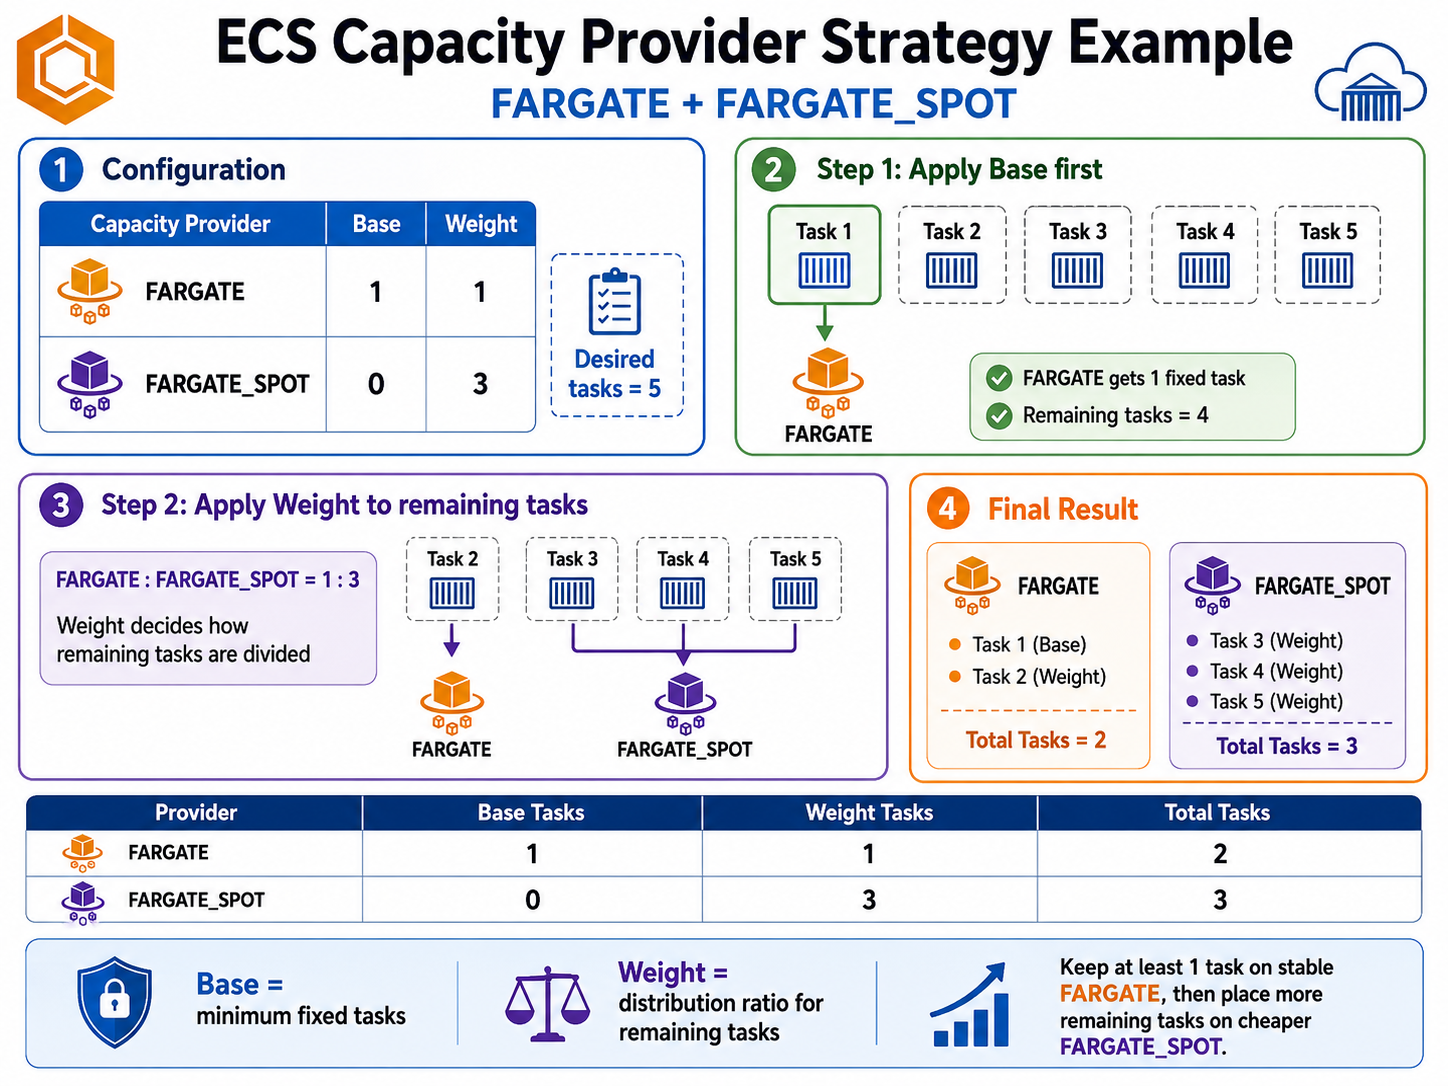

# Check Service and Open API

Go to:

```text
ECS
↓
Cluster
↓
Services
↓
flask-api-service
```

Check:

```text
Desired tasks = 1
Running tasks = 1
```

Get public IP:

```text
Cluster
↓
Tasks
↓
Click running task
↓
Networking
↓
Public IP
```

Open:

```text
http://PUBLIC_IP:5000

http://13.233.246.110:5000
```

Health check:

```text
http://PUBLIC_IP:5000/health
```

# 16. Troubleshooting

| Problem | Reason | Fix |
|---|---|---|
| API not opening | Security group closed | Open port `5000` |
| API not opening | Public IP OFF | Enable public IP |
| Task stopped | App crashed | Check CloudWatch logs |
| Cannot pull image | Wrong image URI/tag | Check ECR image URI |
| Cannot pull image | Missing execution role | Use `ecsTaskExecutionRole` |
| API only works inside container | Flask using `127.0.0.1` | Use `0.0.0.0` |

Most common Flask ECS mistake:

```python
app.run(host="127.0.0.1")
```

Correct:

```python
app.run(host="0.0.0.0", port=5000)
```

### Fix: ECS Flask API Not Opening in Browser

If the Flask API is running in ECS but the browser shows:

```text
This site can't be reached
ERR_CONNECTION_TIMED_OUT
```

then the issue is usually related to **network access**, not Flask code.

In our logs, Flask was running correctly:

```text
Running on all addresses (0.0.0.0)
Running on http://172.31.0.6:5000
```

This means the Flask application is running inside the ECS task, but public internet traffic is not reaching it.

---

#### Step 1: Open ECS Task Networking

Go to:

```text
AWS Console
→ ECS
→ Clusters
→ ecs-demo-cluster2
→ Tasks
→ Click running task
```

Then open:

```text
Networking
```

You will see details like:

```text
Public IP
Private IP
Subnet
Security group
```

---

#### Step 2: Open Security Group

In the **Networking** section, find:

```text
Security group
```

Click on the security group link.

It will open the EC2 Security Group page.

---

#### Step 3: Edit Inbound Rules

Now go to:

```text
Inbound rules
→ Edit inbound rules
```

Click:

```text
Add rule
```

Add this rule:

| Field        | Select / Enter    |
| ------------ | ----------------- |
| Type         | Custom TCP        |
| Protocol     | TCP               |
| Port range   | `5000`            |
| Source       | Anywhere IPv4     |
| Source value | `0.0.0.0/0`       |
| Description  | `Allow Flask API` |

Then click:

```text
Save rules
```

---

#### Step 4: Check Public IP

Go back to:

```text
ECS
→ Cluster
→ Task
→ Networking
```

Copy the **Public IP** of the running task.

Open in browser:

```text
http://PUBLIC_IP:5000
```

Example:

```text
http://52.66.237.53:5000
```

---

#### Important

Do **not** use the private IP shown in logs:

```text
172.31.0.6:5000
```

That is a private AWS network IP.

Use the **public IP** from ECS task networking.

---

#### Correct Setup Checklist

| Check                  | Correct value               |
| ---------------------- | --------------------------- |
| Flask host             | `0.0.0.0`                   |
| Flask port             | `5000`                      |
| ECS task status        | Running                     |
| Public IP              | Enabled                     |
| Security group inbound | TCP `5000` from `0.0.0.0/0` |
| Browser URL            | `http://PUBLIC_IP:5000`     |

---

#### Why This Error Happens

When the browser shows timeout, usually the request is not reaching the ECS task.

Common reasons:

| Issue                                     | Meaning                                          |
| ----------------------------------------- | ------------------------------------------------ |
| Security group does not allow port `5000` | Browser traffic is blocked                       |
| Public IP is disabled                     | Task cannot be accessed directly from internet   |
| Task is in private subnet                 | Direct browser access will not work              |
| Wrong port is used                        | Flask runs on `5000`, but another port is opened |
| Flask runs on `127.0.0.1`                 | App is not listening outside the container       |




# 18. Manual Scaling

Go to:

```text
ECS
↓
Cluster
↓
Service
↓
Update
```

Change:

```text
Desired tasks = 2
```

ECS will run 2 copies of the Flask API.

<span style="color:red">**Without a load balancer, each task may have a different public IP. For production-style setup, use an Application Load Balancer**</span>


# Load Balancer Theory in AWS ECS

### What is a Load Balancer?

A **Load Balancer** is used between the user and ECS tasks.

Simple meaning:

```text
Load Balancer = Traffic Manager
```

It receives incoming user requests and forwards them to the correct running ECS task.

In ECS, a load balancer is mainly used when we are running a web application or API such as:

```text
Flask API
FastAPI API
Node.js API
Django App
Nginx App
```

---

### ECS Without Load Balancer

Suppose our Flask API is running directly on one ECS task.

```text
User Browser
     |
     v
http://52.66.237.53:5000
     |
     v
ECS Task
Flask API
```

Here, the user is directly accessing the **public IP of the ECS task**.

This is okay for learning, but it is not good for production.

---

### Problems Without Load Balancer

| Problem                     | Explanation                                                        |
| --------------------------- | ------------------------------------------------------------------ |
| Public IP can change        | If the ECS task restarts, the new task may get a new public IP     |
| Not good for scaling        | If ECS runs 2 or 3 tasks, each task may have a different public IP |
| Manual tracking needed      | We have to manually find the latest task public IP                 |
| Not production-friendly     | Users should not directly access container public IP               |
| Security issue              | Container port is directly exposed to the internet                 |
| No automatic health routing | If one task fails, traffic may still go to that task               |



---


---

### Load Balancer Components

When we use ECS with a Load Balancer, these components are important.

| Component                 | Meaning                                            |
| ------------------------- | -------------------------------------------------- |
| Application Load Balancer | Receives traffic from users                        |
| Listener                  | Defines which port the load balancer listens on    |
| Target Group              | Group of ECS tasks where traffic is forwarded      |
| Health Check              | Checks whether the ECS task/application is healthy |
| ECS Service               | Registers running ECS tasks with the target group  |

---

### Application Load Balancer

An **Application Load Balancer**, also called **ALB**, works at the application layer.

It is commonly used for:

```text
HTTP
HTTPS
Web applications
APIs
```

For our Flask API, Application Load Balancer is the correct choice.

---

### Listener

A **Listener** defines which port the Load Balancer listens on.

Example:

```text
Listener: HTTP 80
```

This means:

```text
Load Balancer accepts user requests on port 80
```

For normal web traffic:

| Traffic Type | Port |
| ------------ | ---- |
| HTTP         | 80   |
| HTTPS        | 443  |

For our first demo, we can use:

```text
HTTP 80
```


### Port Understanding

Our Flask API runs inside the container on port:

```text
5000
```

But the user may access the Load Balancer on normal web port:

```text
80
```

Flow:

```text
User request on port 80
        |
        v
Application Load Balancer
        |
        v
Forward to ECS task on port 5000
```

| Side                             | Port |
| -------------------------------- | ---- |
| User to Load Balancer            | 80   |
| Load Balancer to Flask Container | 5000 |

So the user can open:

```text
http://load-balancer-dns-name
```

The load balancer internally forwards traffic to:

```text
Flask container on port 5000
```

---

---

### Target Group

A **Target Group** is a group of backend targets where the load balancer sends traffic.

In ECS Fargate, targets are usually ECS tasks.

```text
Application Load Balancer
        |
        v
Target Group
        |
        v
ECS Tasks running Flask API
```

For Fargate, target type should usually be:

```text
IP
```

Because Fargate tasks get their own network interface and IP.

---

### Health Check

Health check means the load balancer keeps checking whether the app is working or not.

For our Flask app, we created this endpoint:

```text
/health
```

Example Flask health route:

```python
@app.route("/health")
def health():
    return jsonify({"status": "healthy"})
```

So in the target group, we can set:

```text
Health check path = /health
```

---

### Health Check Illustration

```text
Load Balancer
     |
     | checks /health
     v

ECS Task 1 → Healthy
ECS Task 2 → Unhealthy
ECS Task 3 → Healthy
```

Load balancer will send traffic only to healthy tasks:

```text
Traffic goes to Task 1 and Task 3
Traffic does not go to Task 2
```

---

### ECS With Load Balancer Flow

```text
User opens browser
        |
        v
Application Load Balancer
        |
        v
Listener: HTTP 80
        |
        v
Target Group
        |
        v
Healthy ECS Tasks
        |
        v
Flask API on port 5000
```

---


### Before and After Comparison

| Without Load Balancer           | With Load Balancer                  |
| ------------------------------- | ----------------------------------- |
| User uses task public IP        | User uses load balancer DNS         |
| IP can change                   | DNS remains stable                  |
| Hard to scale                   | Easy to scale                       |
| No proper health routing        | Sends traffic only to healthy tasks |
| Container port exposed directly | Better security layer               |
| Good for learning only          | Better for production               |

---
```text
Application Load Balancer
↓
Listener: HTTP 80
↓
Target Group
↓
Target type: IP
↓
Health check path: /health
↓
ECS Service
↓
Flask container port: 5000
```

---

### Console Steps Overview

#### Step 1: Create Target Group

Go to:

```text
EC2
→ Target Groups
→ Create target group
```

Use:

| Field             | Value           |
| ----------------- | --------------- |
| Target type       | IP addresses    |
| Protocol          | HTTP            |
| Port              | 5000            |
| VPC               | Same VPC as ECS |
| Health check path | /health         |

---

#### Step 2: Create Application Load Balancer

Go to:

```text
EC2
→ Load Balancers
→ Create Load Balancer
→ Application Load Balancer
```

Use:

| Field          | Value              |
| -------------- | ------------------ |
| Scheme         | Internet-facing    |
| Listener       | HTTP:80            |
| VPC            | Same VPC as ECS    |
| Subnets        | Public subnets     |
| Security group | Allow HTTP 80      |
| Forward to     | Flask target group |


**In security group add this rule**

| Type | Protocol | Port range | Source      |
| ---- | -------- | ---------: | ----------- |
| HTTP | TCP      |         80 | `0.0.0.0/0` |

<span style="color:red">and remove this:</span>


| Type       | Port | Why not needed                                         |
| ---------- | ---: | ------------------------------------------------------ |
| Custom TCP | 5000 | Browser does not directly hit ALB on 5000 in our setup |


---

#### Step 3: Attach Load Balancer to ECS Service

When creating or updating ECS service:

| Field              | Value                     |
| ------------------ | ------------------------- |
| Load balancer type | Application Load Balancer |
| Container          | flask-api-container       |
| Container port     | 5000                      |
| Target group       | Flask target group        |

---

### Final Architecture

```text
User
 |
 | HTTP request
 v
Application Load Balancer
 |
 | HTTP 80
 v
Target Group
 |
 | forwards to port 5000
 v
ECS Service
 |
 | manages running tasks
 v
ECS Tasks
 |
 v
Flask API Container
```

<span style="color:red">Now use ALB DNS to access the API</span>

http://load-balancer2-1019873136.ap-south-1.elb.amazonaws.com

# 21. Scheduled Task Theory

Scheduled ECS task is for jobs, not APIs.

Examples:

```text
Daily ETL
Hourly sync
Nightly reports
```

Flow:

```text
EventBridge Schedule
↓
ECS RunTask
↓
Container runs
↓
Task stops
```

For Flask API: use ECS Service.  
For Python job: use Scheduled ECS Task.

# 22. Clean Up

Delete resources after practice to avoid charges.

## Delete service

```text
ECS
↓
Cluster
↓
Service
↓
Update desired tasks to 0
↓
Delete service
```

## Delete cluster

```text
ECS
↓
Clusters
↓
Delete cluster
```

## Delete load balancer and target group if created

```text
EC2
↓
Load Balancers / Target Groups
↓
Delete
```

## Delete CloudWatch logs if not needed

```text
CloudWatch
↓
Log groups
↓
Delete ECS log groups
```

# 23. Final Summary

Complete flow:

```text
Create Flask API
↓
Dockerize Flask API
↓
Run locally
↓
Push image to ECR
↓
Create ECS Cluster
↓
Create Task Definition
↓
Create ECS Service
↓
Open API using public IP
↓
Later add Load Balancer
```

## Key learning

| Concept | Meaning |
|---|---|
| ECR | Stores Docker images |
| ECS | Runs Docker containers |
| Fargate | Runs containers without EC2 management |
| Task Definition | Blueprint of container |
| Service | Keeps container running |
| Security Group | Controls traffic |
| Load Balancer | Stable URL and traffic distribution |
| CloudWatch Logs | Debug container output |